In [2]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import softmax
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import TextVectorization

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

In [3]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [4]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
dev = tf.config.list_physical_devices()
print('Physical Devices : ', dev)

#tf.config.set_visible_devices(dev[0])
#tf.config.set_visible_devices(dev[1])
dev = tf.config.list_logical_devices()
print('Available Devices : ', dev)

Physical Devices :  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Available Devices :  [LogicalDevice(name='/device:CPU:0', device_type='CPU'), LogicalDevice(name='/device:GPU:0', device_type='GPU')]


I0000 00:00:1750719288.938413   88480 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9273 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


# Chapter 12: Generative Deep Learning

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

Generative AI and using deep learning architectures is particulary popular right now,
though I personally agree with the assessment that it "has fed a (not so) short-lived hype
wave worthy of the most torrid AI summer.  In any case, the promise of generative AI is that
it can be used as a tool to augment human capabilities, so more generative augmentive intelligence
rather than artifical general intelligence.

In this section we will look at some of the basic mechanisms and architectures for building generative
systems using deep learning networks.  We will look at generating text and images, and
what autoencoders and GAN networks are all about.

## 12.5 Generative Adversarial Networks

That’s what a GAN is: a forger network and an expert network, each being trained
to best the other. As such, a GAN is made of two parts:

- Generator network—Takes as input a random vector (a random point in the
  latent space), and decodes it into a synthetic image
- Discriminator network (or adversary)—Takes as input an image (real or synthetic),
  and predicts whether the image came from the training set or was created by
  the generator network

Unlike VAEs, this latent space has fewer explicit guarantees of meaningful
structure; in particular, it isn’t continuous.

Remarkably, a GAN is a system where the optimization minimum isn’t fixed, unlike in
any other training setup you’ve encountered in this book. Normally, gradient descent
consists of rolling down hills in a static loss landscape. But with a GAN, every step
taken down the hill changes the entire landscape a little. It’s a dynamic system where
the optimization process is seeking not a minimum, but an equilibrium between two
forces. For this reason, GANs are notoriously difficult to train—getting a GAN to work
requires lots of careful tuning of the model architecture and training parameters.

### 12.5.1 A Schmeatic GAN Implementation

The specific implementation we’ll use in this demonstration is a deep
convolutional GAN (DCGAN): a very basic GAN where the generator and discriminator
are deep convnets.

We’ll train our GAN on images from the Large-scale CelebFaces Attributes dataset, a dataset
of 200,000 faces of celebrities.

To speed up training, we’ll resize the images to 64 × 64,
so we’ll be learning to generate 64 × 64 images of human faces.

Schematically, the GAN looks like this:

- A generator network maps vectors of shape (latent_dim,) to images of shape (64, 64, 3).
- A discriminator network maps images of shape (64, 64, 3) to a binary score
  estimating the probability that the image is real.
- A gan network chains the generator and the discriminator together: gan(x) =
  discriminator(generator(x)). Thus, this gan network maps latent space vectors
  to the discriminator’s assessment of the realism of these latent vectors as
  decoded by the generator.
- We train the discriminator using examples of real and fake images along with
  “real”/“fake” labels, just as we train any regular image-classification model.
- To train the generator, we use the gradients of the generator’s weights with
  regard to the loss of the gan model. This means that at every step, we move the
  weights of the generator in a direction that makes the discriminator more likely
  to classify as “real” the images decoded by the generator. In other words, we
  train the generator to fool the discriminator.


### 12.5.2 A Bag of Tricks

Here are a few of the tricks used in the implementation of the GAN generator and
discriminator in this section: 

- We use strides instead of pooling for downsampling feature maps in the discriminator,
  just like we did in our VAE encoder.
- We sample points from the latent space using a normal distribution (Gaussian distribution),
  not a uniform distribution.
- Stochasticity is good for inducing robustness. Because GAN training results in a
  dynamic equilibrium, GANs are likely to get stuck in all sorts of ways. Introducing
  randomness during training helps prevent this. We introduce randomness
  by adding random noise to the labels for the discriminator.
- Sparse gradients can hinder GAN training. In deep learning, sparsity is often
  a desirable property, but not in GANs. Two things can induce gradient sparsity:
  max pooling operations and relu activations. Instead of max pooling,
  we recommend using strided convolutions for downsampling, and we recommend
  using a LeakyReLU layer instead of a relu activation. It’s similar to
  relu, but it relaxes sparsity constraints by allowing small negative activation
  values.
- In generated images, it’s common to see checkerboard artifacts caused by
  unequal coverage of the pixel space in the generator. To fix
  this, we use a kernel size that’s divisible by the stride size whenever we use a
  strided Conv2DTranspose or Conv2D in both the generator and the discriminator.

### 12.5.3 Getting Our Hands on the CelebA Dataset

The data is too large to put in our class repository.  You can download the data
from the website: http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html

The data has no direct link to download.  If you go to the website you can click through to a google
drive page.  I downloaded the Aligned and Cropped images as a zip file 
(in the `google drive > CelebA > Img > img_align_celba.zip` directory),
and moved them by hand into my repository `data` subdirectory.

The compressed zip file for the Aligned and Cropped images is 1.3G in size.  Uncompressed
the images take 1.7G of disk space.

Here is an example of downloading and uncompressing the dataset in our class DevEnvironment
`data` subdirectory. 



```
# copied over the zip file by hand here

vscode ➜ /workspaces/nndl/data (main) $ ls -alh
total 1.8G
-rwxrwxrwx 1 root   root   1.4G Jun 23 23:12 img_align_celeba.zip

vscode ➜ /workspaces/nndl/data (main) $ unzip -qq img_align_celeba.zip 
vscode ➜ /workspaces/nndl/data (main) $ du -h -s img_align_celeba
1.7G    img_align_celeba

# save some space and remove the archive after we extract
vscode ➜ /workspaces/nndl/data (main) $ rm img_align_celeba.zip
```

Once you've got the uncompressed images in a directory, you can use
the Keras `image_dataset_from_directory` to turn it into a dataset.

Since we just need the images, there are no labels, we specify `label_mode=None`, and like we
saw in a previous example, it will look through all subdirectory structures and return
all images to be flowed from the dataset instance.

**Note**: The api for `smart_resize` changed, seems was moved to a preprocessing function.

**Note**: As you can imagine, there are 202,599 images in this dataset.  The following
cells will take some time to complete running.

In [8]:
# creating a dataset from a directory of images

# NOTE: looks like typo in the textbook, the function is in keras.utils and
# is named image_dataset_from_directory

# NOTE: the API for smart resizing has changed.  There is a separate smart_resize preprocessing
# function in keras.preprocessing.image.  We use that here

dataset = keras.utils.image_dataset_from_directory(
    "../data/img_align_celeba",
    # only the images will be returned, no labels
    label_mode=None,
    #image_size=(64, 64),
    batch_size=32,
    # we will resize the images to 64x64 by using a smart combination of
    # cropping and resizing to preserve aspect ratio.  We don't want face proportions
    # to get distorted!
    #smart_resize=True
)

image_size = (64, 64)
dataset = dataset.map(lambda image: keras.preprocessing.image.smart_resize(image, image_size))

Found 202599 files.


Also add into the dataset pipeline automatic rescaling of the images to the range `[0 - 1]`

In [9]:
dataset = dataset.map(lambda x: x / 255.0)

Here is a sample image pulled from the dataset.

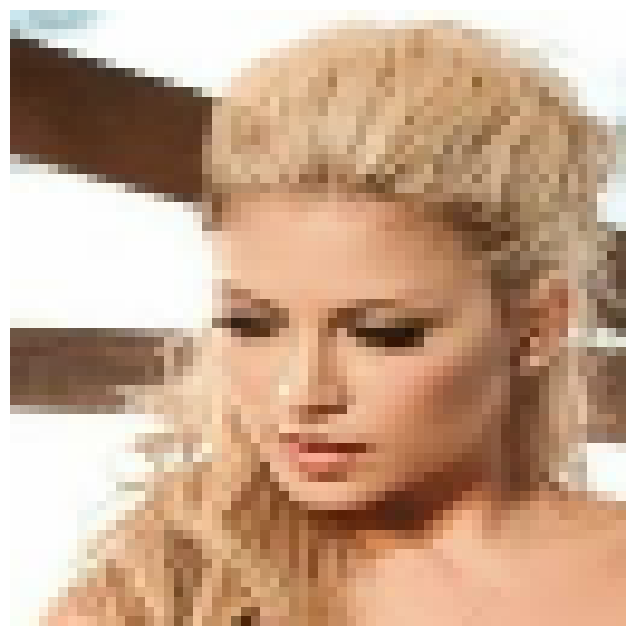

In [10]:
for x in dataset:
    plt.axis("off")
    plt.imshow((x.numpy() * 255).astype("int32")[0])
    break

### 12.5.4 The Discriminator

First, we’ll develop a discriminator model that takes as input a candidate image
(real or synthetic) and classifies it into one of two classes: "generated image" or "real
image that comes from the training set".

One of the many issues that commonly
arise with GANs is that the generator gets stuck with generated images that look like
noise. A possible solution is to use dropout in the discriminator, so that’s what we
will do here.

In [12]:
discriminator = keras.Sequential(
    [
        keras.Input(shape=(64, 64, 3)),
        layers.Conv2D(64, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Conv2D(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Conv2D(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Flatten(),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="discriminator",
)

discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,801 (1.54 MB)

 Trainable params: 404,801 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

### 12.5.5 The Generator

Next, let’s develop a generator model that turns a vector (from the latent space, 
during training it will be sampled at random) into a candidate image.

In [13]:
# GAN generator network

# the latent space will be made of 128-dimensional vectors
latent_dim = 128

generator = keras.Sequential(
    [
        keras.Input(shape=(latent_dim,)),
        # produce the same number of coefficients we had at the level of the Flatten
        # layer in the encoder
        layers.Dense(8 * 8 * 128),
        # revert the Flatten layer of the encoder
        layers.Reshape((8, 8, 128)),
        # revert the Conv2D layers as a sequence of Conv2D transpose and (leaky) ReLU activation
        layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same"),
        # we use LeakyReLU as our activation
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2DTranspose(256, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2DTranspose(512, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(3, kernel_size=5, padding="same", activation="sigmoid"),
    ],
    name="generator",
)

generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 8192)           │     1,056,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 256)    │       524,544 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 512)    │     2,097,664 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 64, 64, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 3)      │        38,403 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,979,651 (15.18 MB)

 Trainable params: 3,979,651 (15.18 MB)

 Non-trainable params: 0 (0.00 B)

### 12.5.6 The Adversarial Network

Finally, we’ll set up the GAN, which chains the generator and the discriminator.

To recapitulate, this is what the training loop looks like schematically. For each
epoch, we do the following:

1. Draw random points in the latent space (random noise).
2. Generate images with generator using this random noise.
3. Mix the generated images with real ones.
4. Train discriminator using these mixed images, with corresponding targets:
   either "real" (for the real images) or "fake" (for the generated images).
5. Draw new random points in the latent space.
6. Train generator using these random vectors, with targets that all say "these are
   real images." This updates the weights of the generator to move them toward
   getting the discriminator to predict "these are real images" for generated
   images: this trains the generator to fool the discriminator.

Let’s implement it. Like in our VAE example, we’ll use a `Model` subclass with a custom
`train_step()`. Note that we’ll use two optimizers (one for the generator and
one for the discriminator), so we will also override `compile()` to allow for passing
two optimizers.


In [14]:
# The GAN Model
class GAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        # set up metrics to track the two losses over each training epoch
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")
    
    def compile(self, d_optimizer, g_optimizer, loss_fn):
        """We need to overrid the compile method to allow for passing 2
        optimizers.
        """
        super(GAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
        """Custom train_step, Train the discriminator and the
        generator in unison.
        """
        # samples random points in the latent space
        batch_size = tf.shape(real_images)[0]
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))

        # decodes them to fake images
        generated_images = self.generator(random_latent_vectors)

        # combines them with real images
        combined_images = tf.concat([generated_images, real_images], axis=0)

        # assemble labels discriminating real from fake images
        labels = tf.concat([tf.ones((batch_size, 1)), tf.zeros((batch_size, 1))],axis=0)
        # adds random noise to the labels, an important trick!
        labels += 0.05 * tf.random.uniform(tf.shape(labels))

        # train the discriminator
        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_weights))

        # samples random points in the latent space
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))

        # assemble lables that say "these are all real images" (it's a lie!)
        misleading_labels = tf.zeros((batch_size, 1))

        # train the generator
        with tf.GradientTape() as tape:
            predictions = self.discriminator(self.generator(random_latent_vectors))
            g_loss = self.loss_fn(misleading_labels, predictions)
            
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)
        return {"d_loss": self.d_loss_metric.result(),
                "g_loss": self.g_loss_metric.result()}

Before we start training, let's also set up a callback to monitor our results.
It will use the generator to create and save a number of fake images at the end of 
each epoch.

In [15]:
class GANMonitor(keras.callbacks.Callback):
    def __init__(self, num_img=3, latent_dim=128):
        self.num_img = num_img
        self.latent_dim = latent_dim
    
    def on_epoch_end(self, epoch, logs=None):
        random_latent_vectors = tf.random.normal(
        shape=(self.num_img, self.latent_dim))
        generated_images = self.model.generator(random_latent_vectors)
        generated_images *= 255
        generated_images.numpy()
        for i in range(self.num_img):
            img = keras.utils.array_to_img(generated_images[i])
            img.save(f"../figures/generated_img_{epoch:03d}_{i}.png")        

Finally we can start training and try it out.

In [16]:
# you'll start getting interesting results after epoch 20, if you can wait that long
epochs = 100

gan = GAN(discriminator=discriminator, generator=generator, latent_dim=latent_dim)

gan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss_fn=keras.losses.BinaryCrossentropy(),
)

gan.fit(
    dataset, epochs=epochs,
    callbacks=[GANMonitor(num_img=10, latent_dim=latent_dim)]
)

Epoch 1/100


I0000 00:00:1750722334.345280   47562 service.cc:152] XLA service 0x4c82fc20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750722334.345310   47562 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-06-23 23:45:34.445356: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-06-23 23:45:34.651923: W tensorflow/compiler/tf2xla/kernels/random_ops.cc:62] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. random_uniform/RandomUniform
I0000 00:00:1750722335.158272   47562 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1750722348.579988   47562 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6332/6332 ━━━━━━━━━━━━━━━━━━━━ 697s 107ms/step - d_loss: 0.5784 - g_loss: 1.3575
Epoch 2/100
6332/6332 ━━━━━━━━━━━━━━━━━━━━ 673s 106ms/step - d_loss: 0.6608 - g_loss: 1.0548
Epoch 3/100
6332/6332 ━━━━━━━━━━━━━━━━━━━━ 675s 107ms/step - d_loss: 0.6613 - g_loss: 0.9863
Epoch 4/100
6332/6332 ━━━━━━━━━━━━━━━━━━━━ 675s 107ms/step - d_loss: 0.6453 - g_loss: 1.0628
Epoch 5/100
6332/6332 ━━━━━━━━━━━━━━━━━━━━ 671s 106ms/step - d_loss: 0.6205 - g_loss: 1.1413
Epoch 6/100
6332/6332 ━━━━━━━━━━━━━━━━━━━━ 668s 106ms/step - d_loss: 0.6319 - g_loss: 1.0793
Epoch 7/100
6332/6332 ━━━━━━━━━━━━━━━━━━━━ 670s 106ms/step - d_loss: 0.6633 - g_loss: 0.9867
Epoch 8/100
6332/6332 ━━━━━━━━━━━━━━━━━━━━ 669s 106ms/step - d_loss: 0.6712 - g_loss: 0.9123
Epoch 9/100
6332/6332 ━━━━━━━━━━━━━━━━━━━━ 670s 106ms/step - d_loss: 0.6617 - g_loss: 0.9047
Epoch 10/100
6332/6332 ━━━━━━━━━━━━━━━━━━━━ 669s 106ms/step - d_loss: 0.6724 - g_loss: 0.9069
Epoch 11/100
6332/6332 ━━━━━━━━━━━━━━━━━━━━ 673s 106ms/step - d_loss: 0.6623 - g_

KeyboardInterrupt: 

When training you may see the adversarial loss begin to increase while the discriminator loss
tends toward 0.  The discriminator may endup dominating the generator.  If that happens try reducing
the discriminator learning rate and increase the dropout rate of the discriminator.

Here is an example of one of the GAN images that were produced

![Example of GAN generated Image](../figures/generated_img_025_5.png)

## Summary

<font color='blue'>
    
- A GAN consists of a generator network coupled with a discriminator network.
  The discriminator is trained to differentiate between the output of the generator
  and real images from a training dataset, and the generator is trained to fool
  the discriminator. Remarkably, the generator never sees images from the training
  set directly; the information it has about the data comes from the discriminator.
- GANs are difficult to train, because training a GAN is a dynamic process rather
  than a simple gradient descent process with a fixed loss landscape. Getting a
  GAN to train correctly requires using a number of heuristic tricks, as well as
  extensive tuning.
- GANs can potentially produce highly realistic images. But unlike VAEs, the
  latent space they learn doesn’t have a neat continuous structure and thus may
  not be suited for certain practical applications, such as image editing via latentspace
  concept vectors.